# 01 - Board representation and bitboards

A chess position breaks up into 12 bitboards (one per piece type and color). Each bitboard is a 64-bit integer, which we can also see as a vector in $\mathrm{GF}(2)^{64}$. Move generation is then a bunch of bitwise ops on these integers, but `python-chess` already does that for us; here we just look at the structure.

If every cell in this notebook runs without error, the engine is wired up correctly.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import chess
import chess.polyglot
import numpy as np
import matplotlib.pyplot as plt

from chess_engine import Evaluator, phi, search_best_move, play_game
from chess_engine.features import _bb_to_array

## Bitboards

Pull the white-knight bitboard out of the starting position and look at it three ways: as an integer, as a binary string, and as an 8x8 numpy array.

In [2]:
board = chess.Board()
white_knights_bb = board.pieces_mask(chess.KNIGHT, chess.WHITE)
print(f'as int      : {white_knights_bb}')
print(f'as binary   : 0b{white_knights_bb:064b}')
print(f'popcount    : {chess.popcount(white_knights_bb)}')

as int      : 66
as binary   : 0b0000000000000000000000000000000000000000000000000000000001000010
popcount    : 2


In [3]:
arr = _bb_to_array(white_knights_bb)
print('as 8x8 array (row 0 = rank 1):')
print(arr)

as 8x8 array (row 0 = rank 1):
[[0 1 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


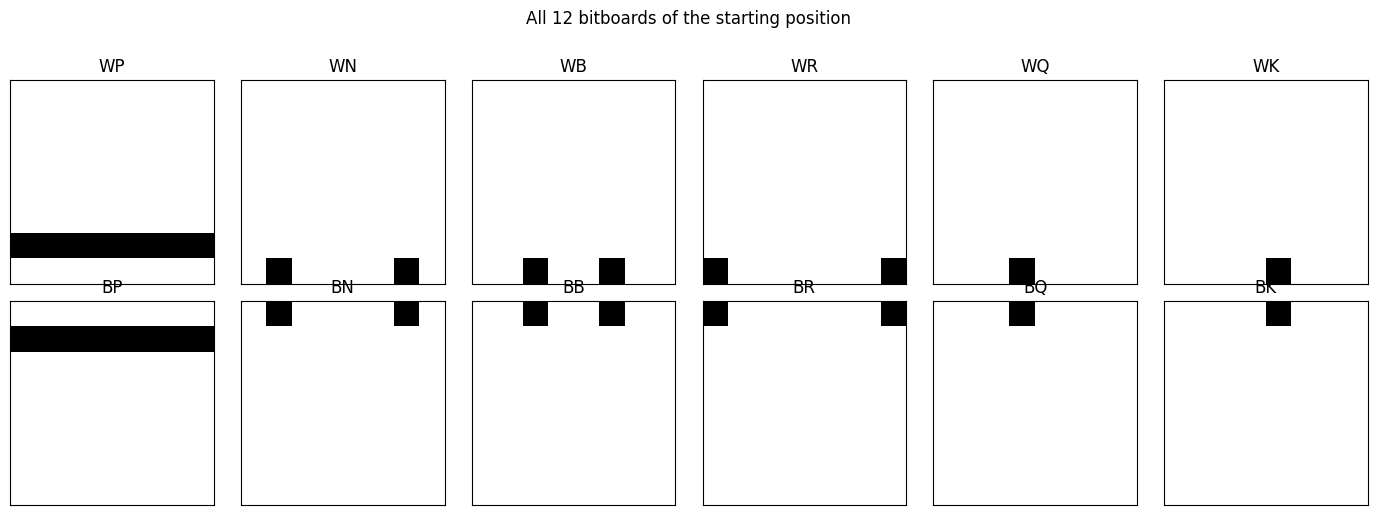

In [4]:
piece_letters = ['P', 'N', 'B', 'R', 'Q', 'K']
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for col, (pt, letter) in enumerate(zip(
        [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING], piece_letters)):
    for row, color in enumerate([chess.WHITE, chess.BLACK]):
        ax = axes[row, col]
        ax.imshow(np.flipud(_bb_to_array(board.pieces_mask(pt, color))),
                  cmap='Greys', vmin=0, vmax=1)
        ax.set_title(f'{"W" if color == chess.WHITE else "B"}{letter}')
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('All 12 bitboards of the starting position', y=1.02)
plt.tight_layout(); plt.show()

## Move generation as bitboard arithmetic

A pawn single-push is just `pawns << 8` masked with the empty squares.

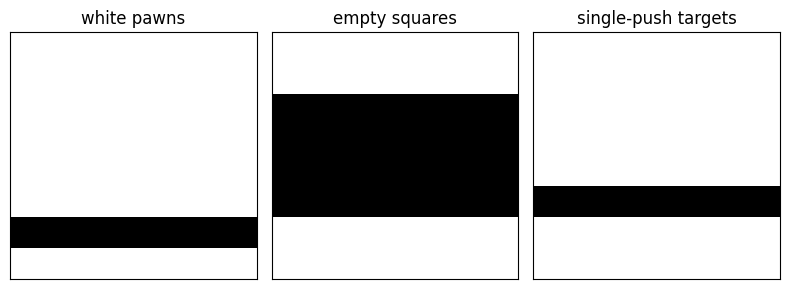

In [5]:
white_pawns = board.pieces_mask(chess.PAWN, chess.WHITE)
empty       = ~int(board.occupied) & 0xFFFFFFFFFFFFFFFF
single_push = (white_pawns << 8) & empty

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for ax, bb, title in zip(
        axes,
        [white_pawns, empty, single_push],
        ['white pawns', 'empty squares', 'single-push targets']):
    ax.imshow(np.flipud(_bb_to_array(bb)), cmap='Greys', vmin=0, vmax=1)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Zobrist hashing

Hash a position by XOR-ing one random 64-bit value per (piece, square, color). `python-chess` does this for us.

In [6]:
h1 = chess.polyglot.zobrist_hash(board)
board.push_san('e4')
h2 = chess.polyglot.zobrist_hash(board)
board.pop()
print(f'hash(start)            = 0x{h1:016x}')
print(f'hash(after e4)         = 0x{h2:016x}')
print(f'hash(start) recomputed = 0x{chess.polyglot.zobrist_hash(board):016x}')

hash(start)            = 0x463b96181691fc9c
hash(after e4)         = 0x823c9b50fd114196
hash(start) recomputed = 0x463b96181691fc9c


## Engine smoke test

Two evaluators play a short game.

In [7]:
white = Evaluator.psqt_handcrafted()
black = Evaluator.material_only()
game = play_game(white, black, depth=2, max_plies=40)
print(game)

[Event "self-play"]
[Site "?"]
[Date "????.??.??"]
[Round "?"]
[White "psqt_handcrafted"]
[Black "material_only"]
[Result "1/2-1/2"]
[Termination "adjudication: ply cap"]

1. Nf3 Nh6 2. d4 Ng8 3. Nc3 Nf6 4. Be3 Rg8 5. Ne5 Rh8 6. Rc1 Rg8 7. h3 Rh8 8. a3 Rg8 9. Nb5 Rh8 10. c3 Rg8 11. Qc2 Rh8 12. Rd1 Rg8 13. Qf5 Rh8 14. c4 Rg8 15. c5 Rh8 16. a4 Rg8 17. a5 Rh8 18. b4 Rg8 19. Bf4 Rh8 20. e3 Rg8 1/2-1/2


## A simple tactic

White rook on a1, undefended black queen on a8. Material-only eval at depth 1 should grab the queen.

best move : Rxa8+
score     : +467 cp (white POV)
nodes     : 3


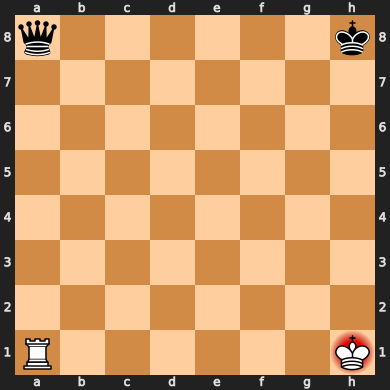

In [8]:
tactic = chess.Board('q6k/8/8/8/8/8/8/R6K w - - 0 1')
result = search_best_move(tactic, depth=1, evaluator=Evaluator.material_only())
print(f'best move : {tactic.san(result.move)}')
print(f'score     : {result.score:+.0f} cp (white POV)')
print(f'nodes     : {result.nodes}')
tactic